In [ ]:
# PART 1: DATA PREPARATION AND EDA

# importing the main libraries I need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# loading the electricity data

df = pd.read_csv("/content/time_series_60min_singleindex_filtered-2.csv")

print(df.head())
print(df.shape)

          utc_timestamp        cet_cest_timestamp  \
0  2014-12-31T23:00:00Z  2015-01-01T00:00:00+0100   
1  2015-01-01T00:00:00Z  2015-01-01T01:00:00+0100   
2  2015-01-01T01:00:00Z  2015-01-01T02:00:00+0100   
3  2015-01-01T02:00:00Z  2015-01-01T03:00:00+0100   
4  2015-01-01T03:00:00Z  2015-01-01T04:00:00+0100   

   DE_load_actual_entsoe_transparency  DE_load_forecast_entsoe_transparency  \
0                                 NaN                                   NaN   
1                             41151.0                               39723.0   
2                             40135.0                               38813.0   
3                             39106.0                               38490.0   
4                             38765.0                               38644.0   

   DE_solar_capacity  DE_solar_generation_actual  DE_solar_profile  \
0            37248.0                         NaN               NaN   
1            37248.0                         NaN               NaN

In [ ]:
# I only need the German actual load column for this assignment

df = df[["utc_timestamp", "DE_load_actual_entsoe_transparency"]]

df.columns = ["timestamp", "load"]

print(df.head())

              timestamp     load
0  2014-12-31T23:00:00Z      NaN
1  2015-01-01T00:00:00Z  41151.0
2  2015-01-01T01:00:00Z  40135.0
3  2015-01-01T02:00:00Z  39106.0
4  2015-01-01T03:00:00Z  38765.0


In [ ]:
# convert timestamp to datetime and use it as the index

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")

print("Start date:", df.index.min())
print("End date:", df.index.max())

Start date: 2014-12-31 23:00:00+00:00
End date: 2020-09-30 23:00:00+00:00


In [ ]:
# the assignment asks to use data from January 2015 onwards

df = df.loc["2015-01-01":]

print(df.head())
print(df.tail())

                              load
timestamp                         
2015-01-01 00:00:00+00:00  41151.0
2015-01-01 01:00:00+00:00  40135.0
2015-01-01 02:00:00+00:00  39106.0
2015-01-01 03:00:00+00:00  38765.0
2015-01-01 04:00:00+00:00  38941.0
                              load
timestamp                         
2020-09-30 19:00:00+00:00  57559.0
2020-09-30 20:00:00+00:00  54108.0
2020-09-30 21:00:00+00:00  49845.0
2020-09-30 22:00:00+00:00  46886.0
2020-09-30 23:00:00+00:00  45461.0


In [ ]:
# checking missing values

print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
load    0
dtype: int64


In [ ]:
# there are no missing values in my filtered load data,
# but I keep interpolation here in case the file has small gaps

df["load"] = df["load"].interpolate()

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
load    0
dtype: int64


In [ ]:
# making daily and weekly versions of the data

daily_load = df["load"].resample("D").mean()
weekly_load = df["load"].resample("W").mean()

print("Daily data:")
print(daily_load.head())

print("Weekly data:")
print(weekly_load.head())

print("Number of weekly observations:", len(weekly_load))

Daily data:
timestamp
2015-01-01 00:00:00+00:00    45346.541667
2015-01-02 00:00:00+00:00    51941.166667
2015-01-03 00:00:00+00:00    46564.750000
2015-01-04 00:00:00+00:00    45082.500000
2015-01-05 00:00:00+00:00    55246.666667
Freq: D, Name: load, dtype: float64
Weekly data:
timestamp
2015-01-04 00:00:00+00:00    47233.739583
2015-01-11 00:00:00+00:00    56191.101190
2015-01-18 00:00:00+00:00    57672.678571
2015-01-25 00:00:00+00:00    58613.303571
2015-02-01 00:00:00+00:00    58734.029762
Freq: W-SUN, Name: load, dtype: float64
Number of weekly observations: 301


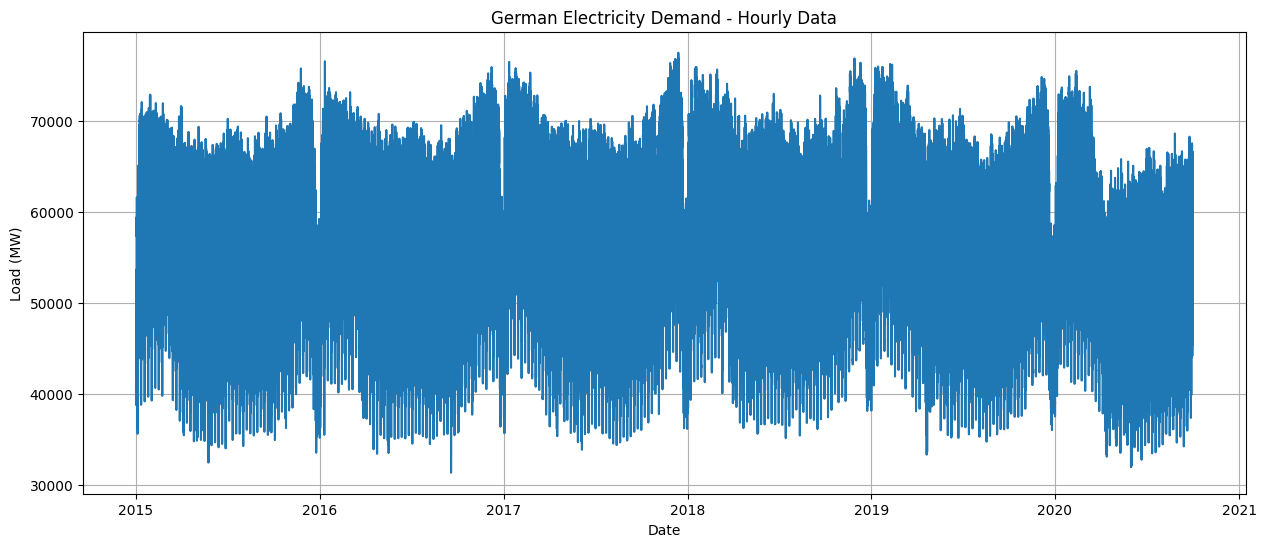

In [ ]:
# plot hourly electricity demand

plt.figure(figsize=(15, 6))
plt.plot(df.index, df["load"])
plt.title("German Electricity Demand - Hourly Data")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.grid(True)
plt.show()

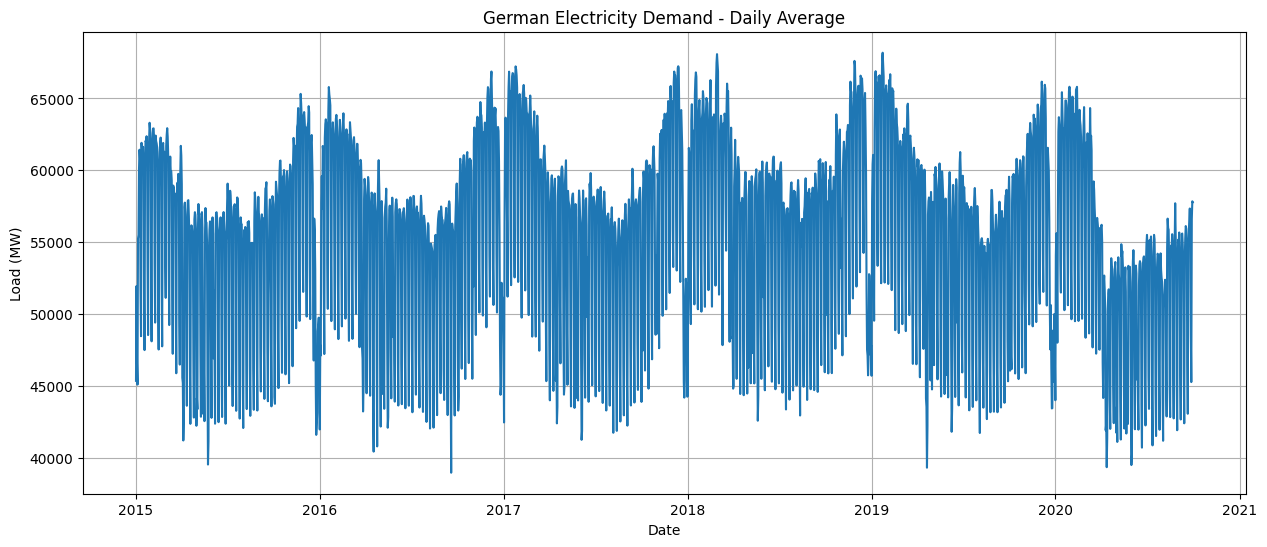

In [ ]:
# plot daily electricity demand

plt.figure(figsize=(15, 6))
plt.plot(daily_load)
plt.title("German Electricity Demand - Daily Average")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.grid(True)
plt.show()

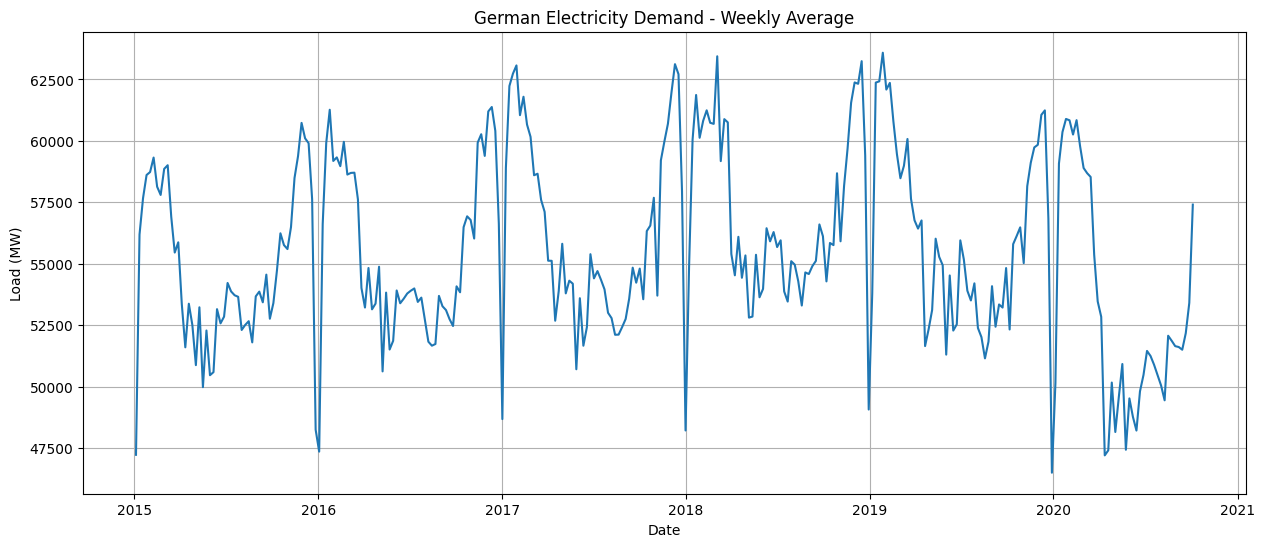

In [ ]:
# plot weekly electricity demand

plt.figure(figsize=(15, 6))
plt.plot(weekly_load)
plt.title("German Electricity Demand - Weekly Average")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.grid(True)
plt.show()

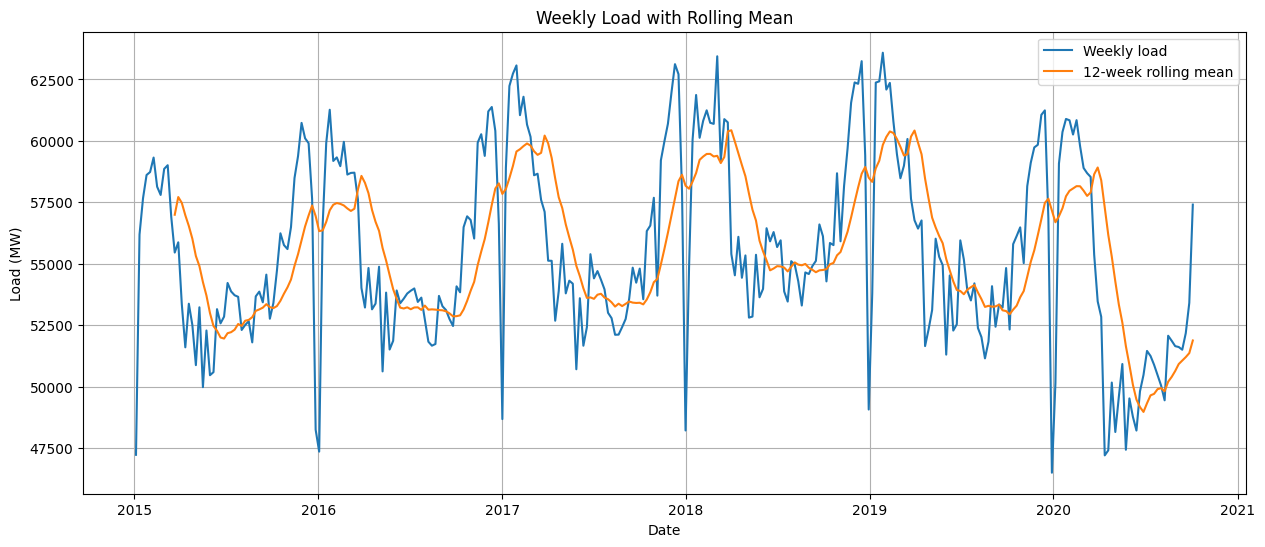

In [ ]:
# rolling mean to see the general trend more clearly

rolling_12 = weekly_load.rolling(12).mean()

plt.figure(figsize=(15, 6))
plt.plot(weekly_load, label="Weekly load")
plt.plot(rolling_12, label="12-week rolling mean")
plt.title("Weekly Load with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True)
plt.show()

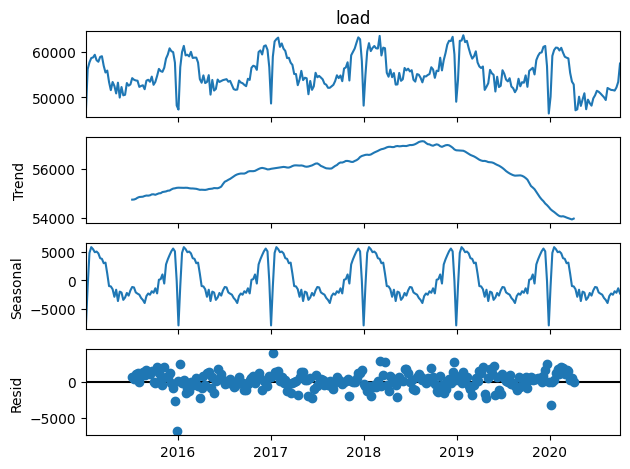

In [ ]:
# seasonal decomposition
# I use 52 because the data is weekly, so 52 weeks is around one year

decomp = seasonal_decompose(
    weekly_load,
    model="additive",
    period=52
)

decomp.plot()
plt.show()

In [ ]:
# ADF test
# H0: series has a unit root / non-stationary
# If p-value < 0.05, I reject H0 and treat the series as stationary

adf_result = adfuller(weekly_load.dropna())

print("ADF Test")
print("ADF statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical values:")

for key, value in adf_result[4].items():
    print(key, ":", value)

if adf_result[1] < 0.05:
    print("ADF result: stationary")
else:
    print("ADF result: non-stationary")

ADF Test
ADF statistic: -4.047471855678481
p-value: 0.0011813497340154584
Critical values:
1% : -3.4529449243622383
5% : -2.871489553425686
10% : -2.572071437887033
ADF result: stationary


In [ ]:
# KPSS test
# H0: series is stationary
# If p-value < 0.05, I reject H0 and treat the series as non-stationary

kpss_result = kpss(
    weekly_load.dropna(),
    regression="c",
    nlags="auto"
)

print("KPSS Test")
print("KPSS statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical values:")

for key, value in kpss_result[3].items():
    print(key, ":", value)

if kpss_result[1] < 0.05:
    print("KPSS result: non-stationary")
else:
    print("KPSS result: stationary")

KPSS Test
KPSS statistic: 0.16037407809773105
p-value: 0.1
Critical values:
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739
KPSS result: stationary


<Figure size 1200x500 with 0 Axes>

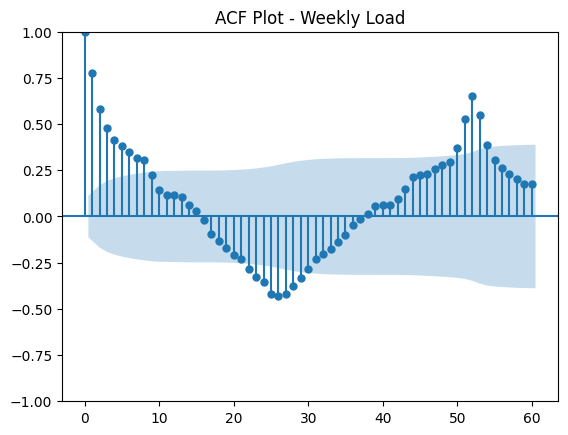

In [ ]:
# ACF plot for weekly load

plt.figure(figsize=(12, 5))
plot_acf(weekly_load.dropna(), lags=60)
plt.title("ACF Plot - Weekly Load")
plt.show()

<Figure size 1200x500 with 0 Axes>

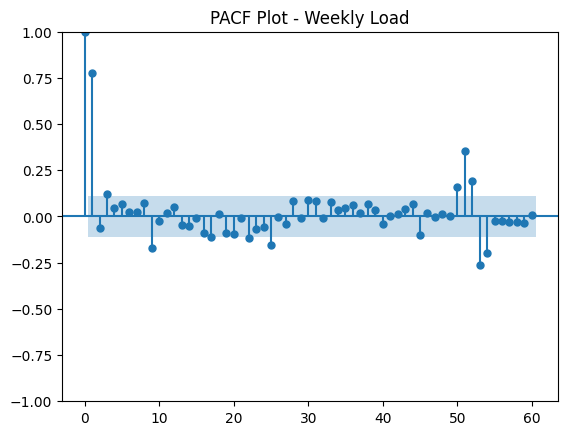

In [ ]:
# PACF plot for weekly load

plt.figure(figsize=(12, 5))
plot_pacf(weekly_load.dropna(), lags=60)
plt.title("PACF Plot - Weekly Load")
plt.show()

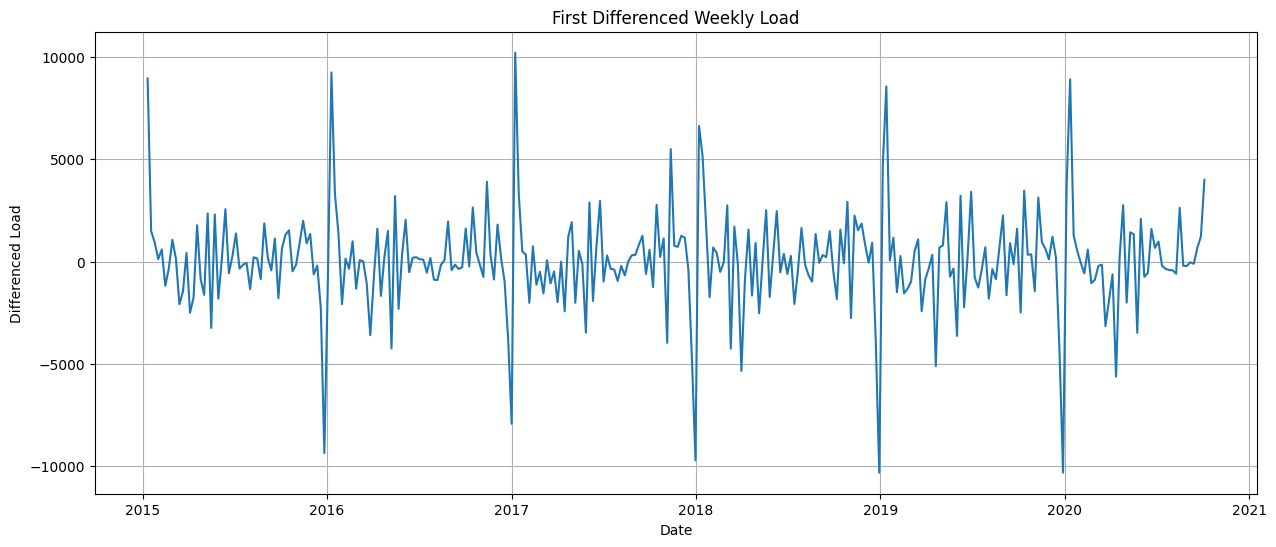

In [ ]:
# first differencing
# I do this to compare stationarity before and after differencing

weekly_diff = weekly_load.diff()

plt.figure(figsize=(15, 6))
plt.plot(weekly_diff)
plt.title("First Differenced Weekly Load")
plt.xlabel("Date")
plt.ylabel("Differenced Load")
plt.grid(True)
plt.show()

In [ ]:
# ADF test after differencing

adf_diff = adfuller(weekly_diff.dropna())

print("ADF Test After Differencing")
print("ADF statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

if adf_diff[1] < 0.05:
    print("Differenced series is stationary according to ADF")
else:
    print("Differenced series is non-stationary according to ADF")

ADF Test After Differencing
ADF statistic: -7.069318170017981
p-value: 4.984737279649426e-10
Differenced series is stationary according to ADF


In [ ]:
# KPSS test after differencing

kpss_diff = kpss(
    weekly_diff.dropna(),
    regression="c",
    nlags="auto"
)

print("KPSS Test After Differencing")
print("KPSS statistic:", kpss_diff[0])
print("p-value:", kpss_diff[1])

if kpss_diff[1] < 0.05:
    print("Differenced series is non-stationary according to KPSS")
else:
    print("Differenced series is stationary according to KPSS")

KPSS Test After Differencing
KPSS statistic: 0.055754419270624765
p-value: 0.1
Differenced series is stationary according to KPSS


<Figure size 1200x500 with 0 Axes>

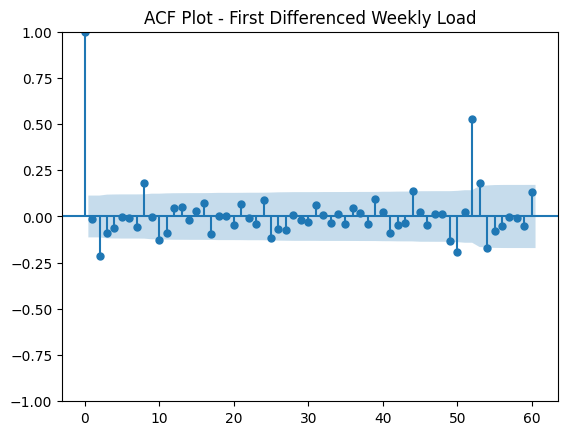

In [ ]:
# ACF after differencing

plt.figure(figsize=(12, 5))
plot_acf(weekly_diff.dropna(), lags=60)
plt.title("ACF Plot - First Differenced Weekly Load")
plt.show()

<Figure size 1200x500 with 0 Axes>

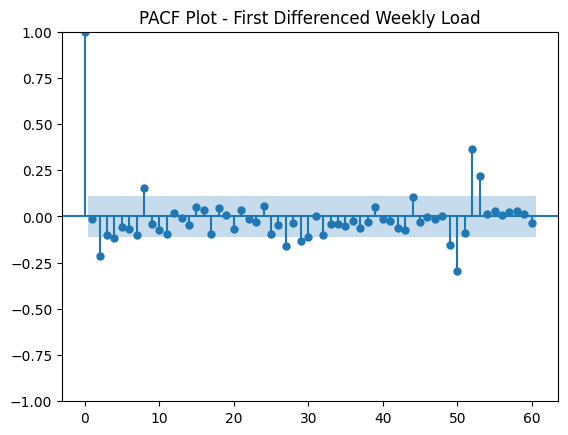

In [ ]:
# PACF after differencing

plt.figure(figsize=(12, 5))
plot_pacf(weekly_diff.dropna(), lags=60)
plt.title("PACF Plot - First Differenced Weekly Load")
plt.show()

In [ ]:
# function for evaluation metrics
# I will reuse this in the next modelling parts

from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(actual, forecast):
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return rmse, mae, mape

In [ ]:
# PART 2: MODELS

# for this assignment I will use the last 104 weeks
# (about 2 years) as the test set

train = weekly_load[:-104]
test = weekly_load[-104:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 197
Testing observations: 104


In [ ]:
# quick check of train and test periods

print("Training starts:", train.index.min())
print("Training ends:", train.index.max())

print("Testing starts:", test.index.min())
print("Testing ends:", test.index.max())

Training starts: 2015-01-04 00:00:00+00:00
Training ends: 2018-10-07 00:00:00+00:00
Testing starts: 2018-10-14 00:00:00+00:00
Testing ends: 2020-10-04 00:00:00+00:00


In [ ]:
# evaluation function
# I will reuse this for all benchmark models

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

def evaluate(actual, forecast):

    rmse = np.sqrt(
        mean_squared_error(actual, forecast)
    )

    mae = mean_absolute_error(
        actual,
        forecast
    )

    mape = np.mean(
        np.abs((actual - forecast) / actual)
    ) * 100

    return rmse, mae, mape

In [ ]:
# mean forecast uses the average of the training data

mean_forecast = np.repeat(
    train.mean(),
    len(test)
)

mean_rmse, mean_mae, mean_mape = evaluate(
    test,
    mean_forecast
)

print("Mean Forecast")
print("RMSE:", mean_rmse)
print("MAE:", mean_mae)
print("MAPE:", mean_mape)

Mean Forecast
RMSE: 4397.29969422285
MAE: 3788.8331219242546
MAPE: 6.96923835716112


In [ ]:
# naive forecast uses the final value from the training set

naive_forecast = np.repeat(
    train.iloc[-1],
    len(test)
)

naive_rmse, naive_mae, naive_mape = evaluate(
    test,
    naive_forecast
)

print("Naive Forecast")
print("RMSE:", naive_rmse)
print("MAE:", naive_mae)
print("MAPE:", naive_mape)

Naive Forecast
RMSE: 4459.108546494938
MAE: 3783.2029342185588
MAPE: 6.790081967086296


In [ ]:
# weekly data has yearly seasonality
# 52 weeks = roughly 1 year

season_length = 52

seasonal_naive = []

for i in range(len(test)):

    value = train.iloc[
        -season_length + (i % season_length)
    ]

    seasonal_naive.append(value)

seasonal_naive = np.array(
    seasonal_naive
)

In [ ]:
sn_rmse, sn_mae, sn_mape = evaluate(
    test,
    seasonal_naive
)

print("Seasonal Naive Forecast")
print("RMSE:", sn_rmse)
print("MAE:", sn_mae)
print("MAPE:", sn_mape)

Seasonal Naive Forecast
RMSE: 3006.7608119599954
MAE: 2318.5205853174602
MAPE: 4.408919739301198


In [ ]:
# drift forecast assumes the trend continues

drift_forecast = []

first_value = train.iloc[0]
last_value = train.iloc[-1]

n = len(train)

slope = (
    last_value - first_value
) / (n - 1)

for h in range(1, len(test) + 1):

    prediction = (
        last_value +
        h * slope
    )

    drift_forecast.append(
        prediction
    )

drift_forecast = np.array(
    drift_forecast
)

In [ ]:
drift_rmse, drift_mae, drift_mape = evaluate(
    test,
    drift_forecast
)

print("Drift Forecast")
print("RMSE:", drift_rmse)
print("MAE:", drift_mae)
print("MAPE:", drift_mape)

Drift Forecast
RMSE: 5117.957264105131
MAE: 4339.890674447435
MAPE: 8.049685103165077


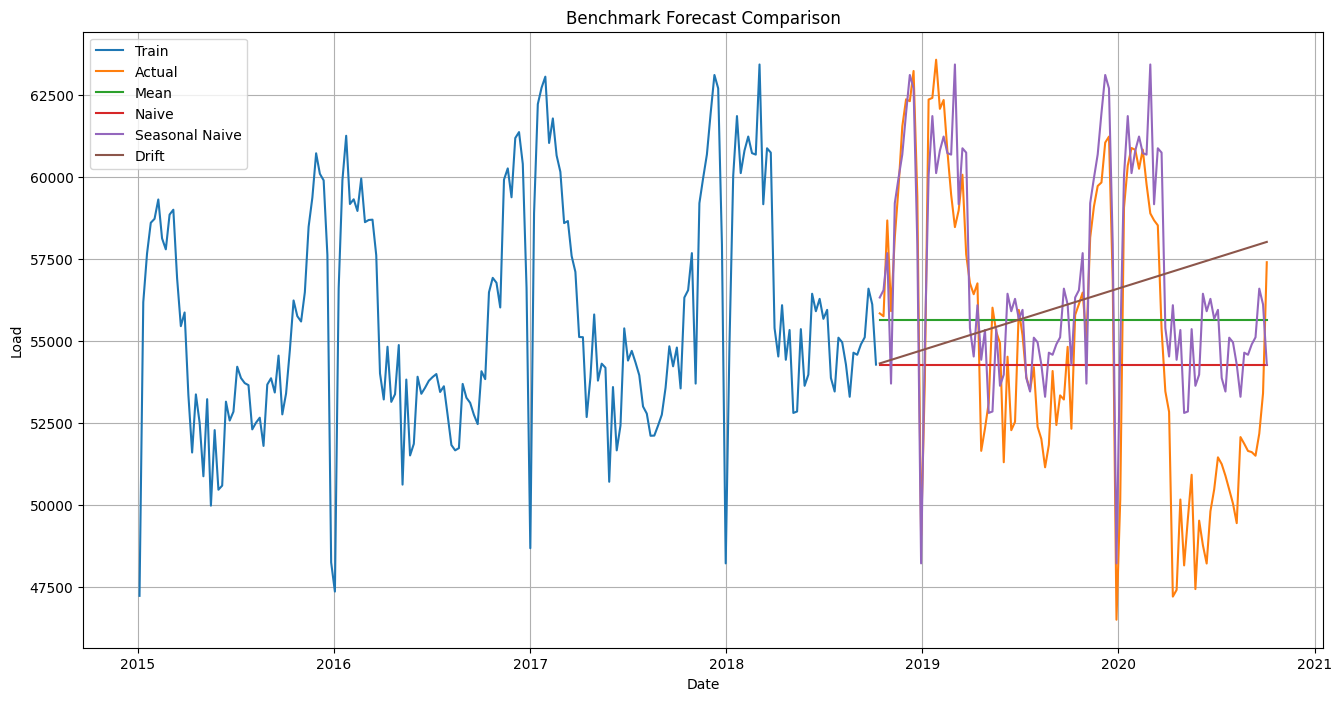

In [ ]:
# comparing all models forecasts together

plt.figure(figsize=(16,8))

plt.plot(
    train.index,
    train,
    label="Train"
)

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    test.index,
    mean_forecast,
    label="Mean"
)

plt.plot(
    test.index,
    naive_forecast,
    label="Naive"
)

plt.plot(
    test.index,
    seasonal_naive,
    label="Seasonal Naive"
)

plt.plot(
    test.index,
    drift_forecast,
    label="Drift"
)

plt.title(
    "Benchmark Forecast Comparison"
)

plt.xlabel("Date")
plt.ylabel("Load")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_results = pd.DataFrame({

    "Model": [
        "Mean",
        "Naive",
        "Seasonal Naive",
        "Drift"
    ],

    "RMSE": [
        mean_rmse,
        naive_rmse,
        sn_rmse,
        drift_rmse
    ],

    "MAE": [
        mean_mae,
        naive_mae,
        sn_mae,
        drift_mae
    ],

    "MAPE": [
        mean_mape,
        naive_mape,
        sn_mape,
        drift_mape
    ]

})

best_results.sort_values(
    "RMSE"
)

,Model,RMSE,MAE,MAPE
2,Seasonal Naive,3006.760812,2318.520585,4.408920
0,Mean,4397.299694,3788.833122,6.969238
1,Naive,4459.108546,3783.202934,6.790082
3,Drift,5117.957264,4339.890674,8.049685


In [ ]:
best_benchmark = best_results.sort_values(
    "RMSE"
).iloc[0]

print("Best Benchmark Model")
print(best_benchmark)

Best Benchmark Model
Model    Seasonal Naive
RMSE        3006.760812
MAE         2318.520585
MAPE            4.40892
Name: 2, dtype: object


In [ ]:
# =========================
# PART 3: SARIMA MODEL
# =========================

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf

In [ ]:
# I use the same train and test split as the benchmark models

train = weekly_load[:-104]
test = weekly_load[-104:]

print("Train length:", len(train))
print("Test length:", len(test))

Train length: 197
Test length: 104


In [ ]:
# weekly data has annual seasonality, so I use 52 weeks
# I keep the seasonal part fixed while testing different p, d and q values

seasonal_period = 52
seasonal_order = (1, 1, 1, seasonal_period)

In [ ]:
# AIC grid search required by the assignment
# p = 0 to 6
# d = 0 to 2
# q = 0 to 6

p_values = range(0, 7)
d_values = range(0, 3)
q_values = range(0, 7)

best_aic = 999999
best_order_aic = None
best_model_aic = None

aic_results = []

for p in p_values:
    for d in d_values:
        for q in q_values:

            order = (p, d, q)

            try:
                model = SARIMAX(
                    train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                fitted = model.fit(disp=False)

                aic_results.append([
                    order,
                    seasonal_order,
                    fitted.aic
                ])

                print("SARIMA", order, "AIC:", round(fitted.aic, 2))

                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order_aic = order
                    best_model_aic = fitted

            except:
                print("SARIMA", order, "failed")

SARIMA (0, 0, 0) AIC: 1635.34
SARIMA (0, 0, 1) AIC: 1603.93
SARIMA (0, 0, 2) AIC: 1585.54
SARIMA (0, 0, 3) AIC: 1560.74
SARIMA (0, 0, 4) AIC: 1541.19
SARIMA (0, 0, 5) AIC: 1527.51
SARIMA (0, 0, 6) AIC: 1508.72
SARIMA (0, 1, 0) AIC: 1617.86
SARIMA (0, 1, 1) AIC: 1582.12
SARIMA (0, 1, 2) AIC: 1564.7
SARIMA (0, 1, 3) AIC: 1546.17
SARIMA (0, 1, 4) AIC: 1527.85
SARIMA (0, 1, 5) AIC: 1509.06
SARIMA (0, 1, 6) AIC: 1490.46
SARIMA (0, 2, 0) AIC: 1697.13
SARIMA (0, 2, 1) AIC: 1604.33
SARIMA (0, 2, 2) AIC: 1567.79
SARIMA (0, 2, 3) AIC: 1546.12
SARIMA (0, 2, 4) AIC: 1521.07
SARIMA (0, 2, 5) AIC: 1503.3
SARIMA (0, 2, 6) AIC: 1485.82
SARIMA (1, 0, 0) AIC: 1614.01
SARIMA (1, 0, 1) AIC: 1594.24
SARIMA (1, 0, 2) AIC: 1576.89
SARIMA (1, 0, 3) AIC: 1562.18
SARIMA (1, 0, 4) AIC: 1546.58
SARIMA (1, 0, 5) AIC: 1529.69
SARIMA (1, 0, 6) AIC: 1511.48
SARIMA (1, 1, 0) AIC: 1606.41
SARIMA (1, 1, 1) AIC: 1579.99
SARIMA (1, 1, 2) AIC: 1564.26
SARIMA (1, 1, 3) AIC: 1546.79
SARIMA (1, 1, 4) AIC: 1529.23
SARIMA (1, 1

In [ ]:
# putting the AIC search results into a table

aic_table = pd.DataFrame(
    aic_results,
    columns=["Order", "Seasonal Order", "AIC"]
)

aic_table.sort_values("AIC").head(10)

,Order,Seasonal Order,AIC
62,"(2, 2, 6)","(1, 1, 1, 52)",1482.273745
41,"(1, 2, 6)","(1, 1, 1, 52)",1482.984883
83,"(3, 2, 6)","(1, 1, 1, 52)",1483.610488
104,"(4, 2, 6)","(1, 1, 1, 52)",1485.256042
20,"(0, 2, 6)","(1, 1, 1, 52)",1485.816904
125,"(5, 2, 6)","(1, 1, 1, 52)",1486.686705
146,"(6, 2, 6)","(1, 1, 1, 52)",1488.235692
13,"(0, 1, 6)","(1, 1, 1, 52)",1490.461384
34,"(1, 1, 6)","(1, 1, 1, 52)",1491.630999
55,"(2, 1, 6)","(1, 1, 1, 52)",1493.576695


In [ ]:
print("Best model according to AIC")
print("Order:", best_order_aic)
print("Seasonal order:", seasonal_order)
print("AIC:", best_aic)

Best model according to AIC
Order: (2, 2, 6)
Seasonal order: (1, 1, 1, 52)
AIC: 1482.2737450303673


In [ ]:
# forecast using the best AIC model

aic_forecast_object = best_model_aic.get_forecast(
    steps=104
)

aic_forecast = aic_forecast_object.predicted_mean
aic_ci = aic_forecast_object.conf_int()

aic_rmse, aic_mae, aic_mape = evaluate(
    test,
    aic_forecast
)

print("Best AIC SARIMA")
print("RMSE:", aic_rmse)
print("MAE:", aic_mae)
print("MAPE:", aic_mape)

Best AIC SARIMA
RMSE: 9470.263043994419
MAE: 8108.347597185939
MAPE: 15.243801304707336


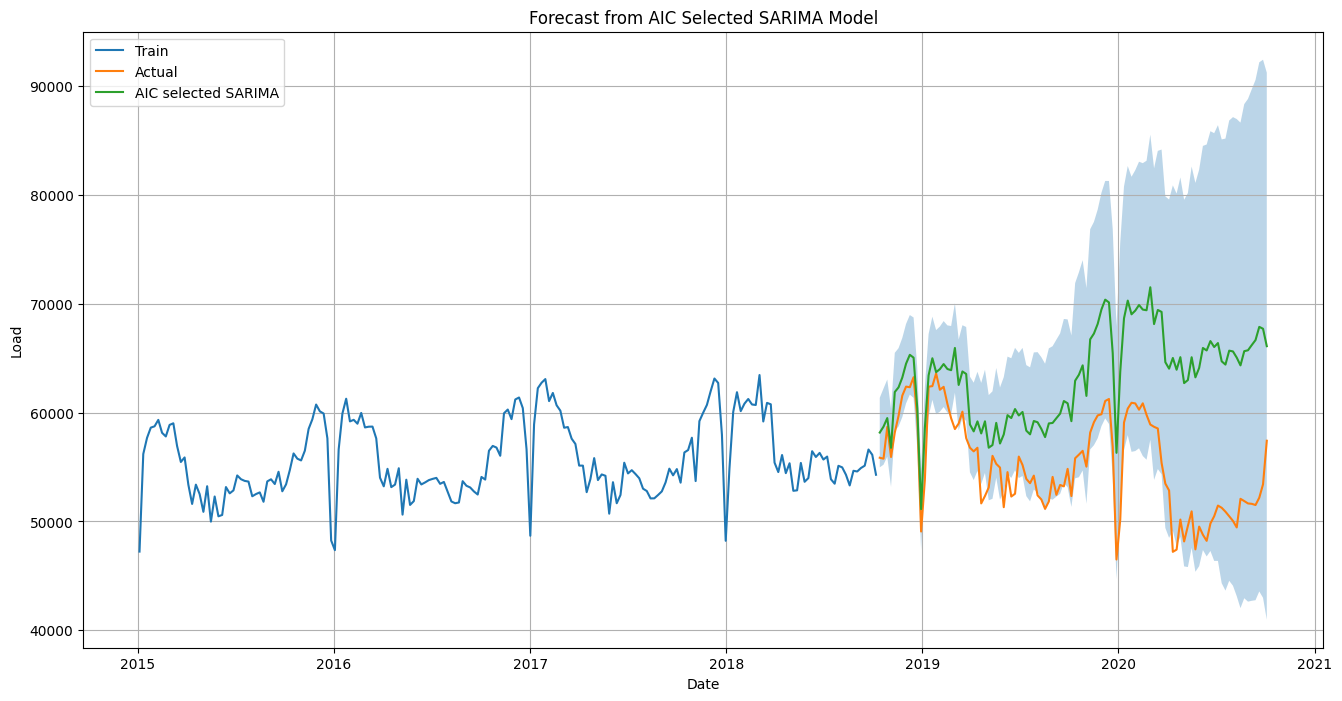

In [ ]:
# plot the AIC-selected model forecast

plt.figure(figsize=(16, 8))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, aic_forecast, label="AIC selected SARIMA")

plt.fill_between(
    test.index,
    aic_ci.iloc[:, 0],
    aic_ci.iloc[:, 1],
    alpha=0.3
)

plt.title("Forecast from AIC Selected SARIMA Model")
plt.xlabel("Date")
plt.ylabel("Load")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# The ADF and KPSS results suggested the weekly series was stationary.
# So I also test a few simpler models with d = 0.

candidate_orders = [
    (0, 0, 1),
    (1, 0, 0),
    (1, 0, 1),
    (2, 0, 0),
    (2, 0, 1),
    (2, 0, 2),
    (3, 0, 1),
    (3, 0, 2),
    (4, 0, 1),
    (6, 0, 0)
]

simple_results = []

for order in candidate_orders:

    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(disp=False)

        forecast = fitted.get_forecast(
            steps=104
        ).predicted_mean

        rmse, mae, mape = evaluate(
            test,
            forecast
        )

        simple_results.append([
            order,
            seasonal_order,
            fitted.aic,
            rmse,
            mae,
            mape
        ])

        print(order, "AIC:", round(fitted.aic, 2), "RMSE:", round(rmse, 2))

    except:
        print(order, "failed")

(0, 0, 1) AIC: 1603.93 RMSE: 2812.77
(1, 0, 0) AIC: 1614.01 RMSE: 2828.4
(1, 0, 1) AIC: 1594.24 RMSE: 2824.95
(2, 0, 0) AIC: 1593.52 RMSE: 2839.65
(2, 0, 1) AIC: 1595.72 RMSE: 2827.38
(2, 0, 2) AIC: 1581.23 RMSE: 2798.54
(3, 0, 1) AIC: 1580.69 RMSE: 2809.72
(3, 0, 2) AIC: 1581.75 RMSE: 2788.72
(4, 0, 1) AIC: 1563.21 RMSE: 2793.97
(6, 0, 0) AIC: 1525.99 RMSE: 2831.24


In [ ]:
# table for simpler SARIMA models

simple_table = pd.DataFrame(
    simple_results,
    columns=[
        "Order",
        "Seasonal Order",
        "AIC",
        "RMSE",
        "MAE",
        "MAPE"
    ]
)

simple_table.sort_values("RMSE")

,Order,Seasonal Order,AIC,RMSE,MAE,MAPE
7,"(3, 0, 2)","(1, 1, 1, 52)",1581.750621,2788.722820,2149.284885,4.094311
8,"(4, 0, 1)","(1, 1, 1, 52)",1563.206553,2793.973009,2153.843691,4.103119
5,"(2, 0, 2)","(1, 1, 1, 52)",1581.233129,2798.539760,2158.926886,4.112319
6,"(3, 0, 1)","(1, 1, 1, 52)",1580.686841,2809.715444,2168.191084,4.129813
0,"(0, 0, 1)","(1, 1, 1, 52)",1603.930037,2812.765272,2156.380551,4.109431
2,"(1, 0, 1)","(1, 1, 1, 52)",1594.238106,2824.951973,2179.858842,4.151643
4,"(2, 0, 1)","(1, 1, 1, 52)",1595.716395,2827.375539,2182.281093,4.155946
1,"(1, 0, 0)","(1, 1, 1, 52)",1614.007596,2828.399017,2174.657823,4.143088
9,"(6, 0, 0)","(1, 1, 1, 52)",1525.994627,2831.240210,2189.036943,4.168094
3,"(2, 0, 0)","(1, 1, 1, 52)",1593.519064,2839.650367,2189.473191,4.170038


In [ ]:
# I choose the final SARIMA model based on the best test RMSE
# This is because the lowest AIC model did not forecast well on the test set

best_simple = simple_table.sort_values(
    "RMSE"
).iloc[0]

final_order = best_simple["Order"]
final_seasonal_order = best_simple["Seasonal Order"]

print("Final SARIMA model")
print(best_simple)

Final SARIMA model
Order                 (3, 0, 2)
Seasonal Order    (1, 1, 1, 52)
AIC                 1581.750621
RMSE                 2788.72282
MAE                 2149.284885
MAPE                   4.094311
Name: 7, dtype: object


In [ ]:
# fit the final SARIMA model

sarima_model = SARIMAX(
    train,
    order=final_order,
    seasonal_order=final_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  197
Model:             SARIMAX(3, 0, 2)x(1, 1, [1], 52)   Log Likelihood                -782.875
Date:                              Thu, 25 Jun 2026   AIC                           1581.751
Time:                                      13:31:17   BIC                           1601.749
Sample:                                  01-04-2015   HQIC                          1589.815
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3892      0.548      0.710      0.478      -0.685       1.464
ar.L2          0.40

In [ ]:
# forecast the final 104 weeks

sarima_forecast_object = sarima_fit.get_forecast(
    steps=104
)

sarima_forecast = sarima_forecast_object.predicted_mean
sarima_ci = sarima_forecast_object.conf_int()

In [ ]:
# evaluate the final SARIMA model

sarima_rmse, sarima_mae, sarima_mape = evaluate(
    test,
    sarima_forecast
)

print("Final SARIMA")
print("RMSE:", sarima_rmse)
print("MAE:", sarima_mae)
print("MAPE:", sarima_mape)

Final SARIMA
RMSE: 2788.722819544552
MAE: 2149.2848851366316
MAPE: 4.094310531412814


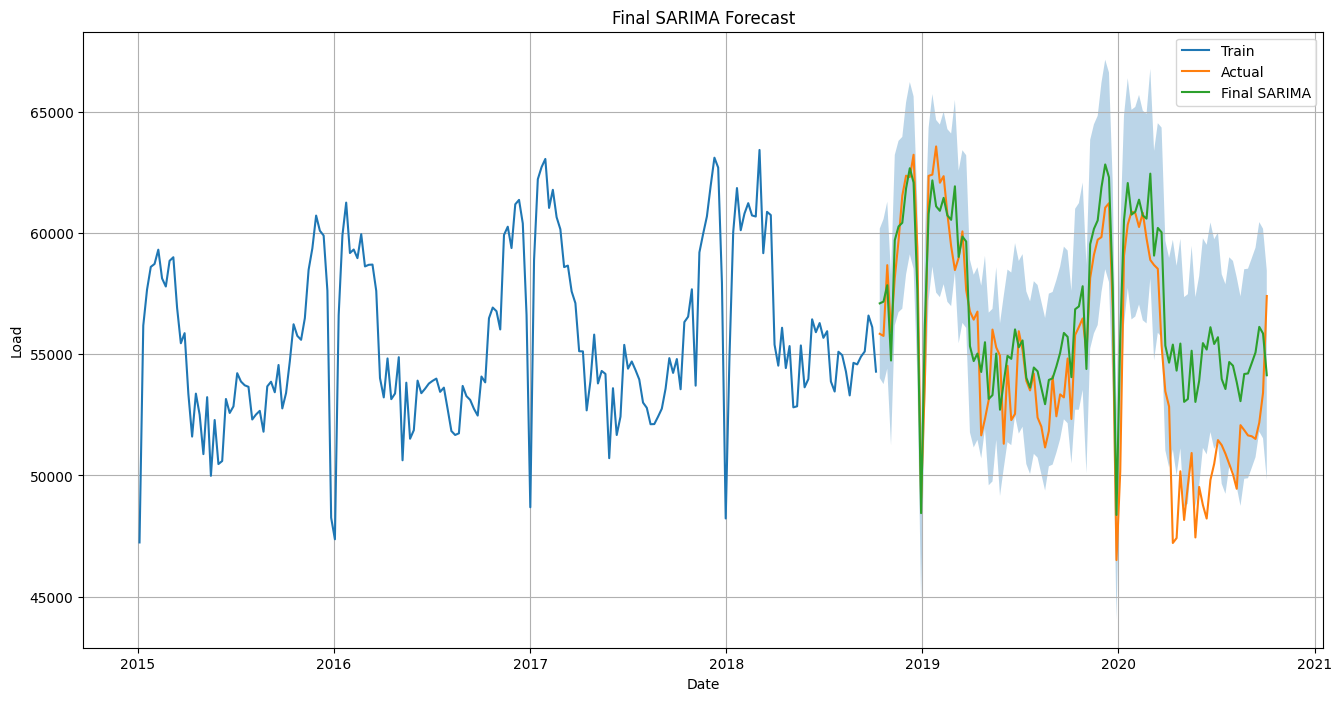

In [ ]:
# final SARIMA forecast plot with confidence intervals

plt.figure(figsize=(16, 8))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, sarima_forecast, label="Final SARIMA")

plt.fill_between(
    test.index,
    sarima_ci.iloc[:, 0],
    sarima_ci.iloc[:, 1],
    alpha=0.3
)

plt.title("Final SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Load")
plt.legend()
plt.grid(True)
plt.show()

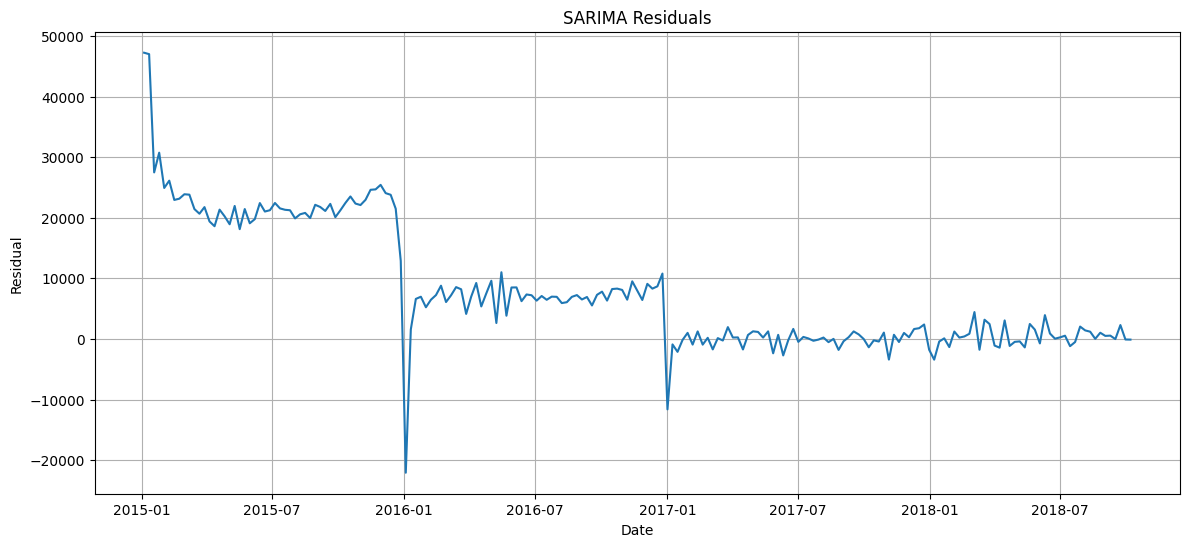

In [ ]:
# residual diagnostics

residuals = sarima_fit.resid

plt.figure(figsize=(14, 6))
plt.plot(residuals)
plt.title("SARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

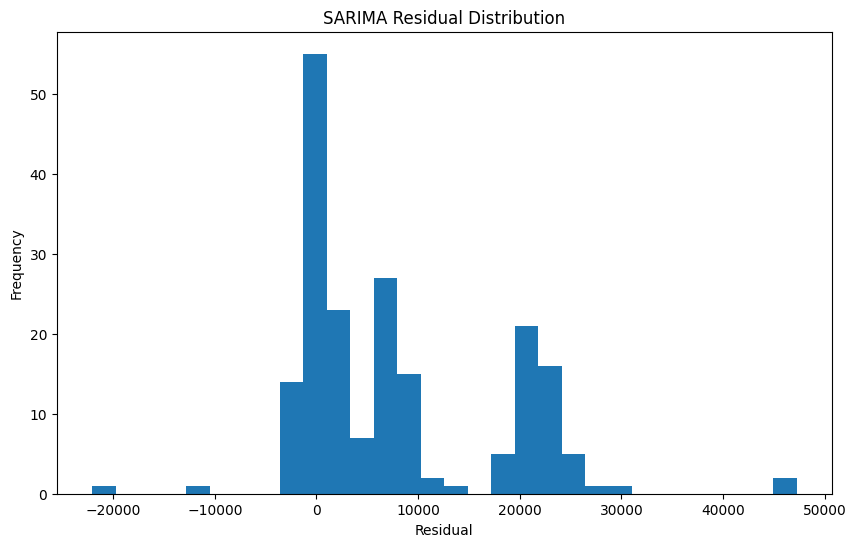

In [ ]:
# residual distribution

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30)
plt.title("SARIMA Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

<Figure size 1200x500 with 0 Axes>

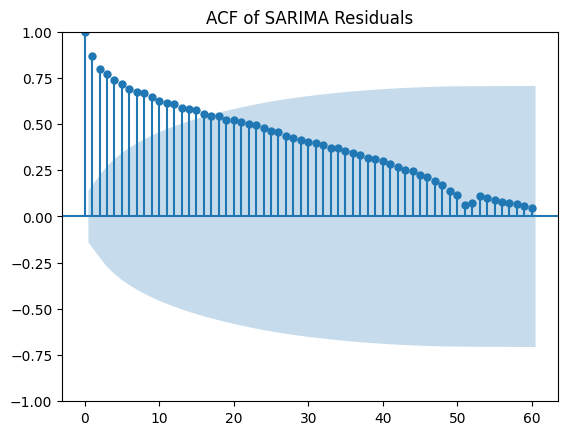

In [ ]:
# ACF plot of residuals
# this checks if there is still autocorrelation left in the residuals

plt.figure(figsize=(12, 5))
plot_acf(residuals.dropna(), lags=60)
plt.title("ACF of SARIMA Residuals")
plt.show()

In [ ]:
# comparing SARIMA with the seasonal naive benchmark

part3_results = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "AIC Selected SARIMA",
        "Final SARIMA"
    ],
    "RMSE": [
        sn_rmse,
        aic_rmse,
        sarima_rmse
    ],
    "MAE": [
        sn_mae,
        aic_mae,
        sarima_mae
    ],
    "MAPE": [
        sn_mape,
        aic_mape,
        sarima_mape
    ]
})

part3_results.sort_values("RMSE")

,Model,RMSE,MAE,MAPE
2,Final SARIMA,2788.722820,2149.284885,4.094311
0,Seasonal Naive,3006.760812,2318.520585,4.408920
1,AIC Selected SARIMA,9470.263044,8108.347597,15.243801


In [ ]:
# =========================
# PART 4: SARIMAX WITH TEMPERATURE
# =========================

# In this part I add Berlin temperature as an external variable.
# This is an explanatory/conditional forecast because future observed
# temperature is used for the test period.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
# download daily Berlin temperature data from Open-Meteo archive API

temp_url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=52.52&longitude=13.41"
    "&start_date=2015-01-01"
    "&end_date=2020-09-30"
    "&daily=temperature_2m_mean"
    "&timezone=UTC"
)

temp_raw = pd.read_json(temp_url)

print(temp_raw.head())

                     latitude  longitude  generationtime_ms  \
time                 52.54833  13.407822          39.818168   
temperature_2m_mean  52.54833  13.407822          39.818168   

                     utc_offset_seconds timezone timezone_abbreviation  \
time                                  0      GMT                   GMT   
temperature_2m_mean                   0      GMT                   GMT   

                     elevation daily_units  \
time                        38     iso8601   
temperature_2m_mean         38          °C   

                                                                 daily  
time                 [2015-01-01, 2015-01-02, 2015-01-03, 2015-01-0...  
temperature_2m_mean  [2.6, 4.9, 3.8, 2.8, 2.9, 1.0, 2.2, 3.4, 6.1, ...  


In [ ]:
# the temperature data is inside the daily column,
# so I convert it into a normal dataframe

temp_daily = pd.DataFrame({
    "date": temp_raw["daily"]["time"],
    "temperature": temp_raw["daily"]["temperature_2m_mean"]
})

temp_daily["date"] = pd.to_datetime(temp_daily["date"])
temp_daily = temp_daily.set_index("date")

print(temp_daily.head())
print(temp_daily.tail())

            temperature
date                   
2015-01-01          2.6
2015-01-02          4.9
2015-01-03          3.8
2015-01-04          2.8
2015-01-05          2.9
            temperature
date                   
2020-09-26         10.5
2020-09-27          9.7
2020-09-28         12.7
2020-09-29         13.3
2020-09-30         12.9


In [ ]:
# convert the daily temperature into weekly average temperature

weekly_temp = temp_daily["temperature"].resample("W").mean()

# my load data index has UTC timezone, so I add UTC to temperature index as well
weekly_temp.index = weekly_temp.index.tz_localize("UTC")

print(weekly_temp.head())
print(weekly_temp.tail())

date
2015-01-04 00:00:00+00:00    3.525000
2015-01-11 00:00:00+00:00    3.914286
2015-01-18 00:00:00+00:00    4.842857
2015-01-25 00:00:00+00:00    0.057143
2015-02-01 00:00:00+00:00    1.400000
Freq: W-SUN, Name: temperature, dtype: float64
date
2020-09-06 00:00:00+00:00    15.942857
2020-09-13 00:00:00+00:00    16.485714
2020-09-20 00:00:00+00:00    17.214286
2020-09-27 00:00:00+00:00    15.000000
2020-10-04 00:00:00+00:00    12.966667
Freq: W-SUN, Name: temperature, dtype: float64


In [ ]:
# combine weekly electricity load and weekly Berlin temperature

sarimax_data = pd.DataFrame({
    "load": weekly_load,
    "temperature": weekly_temp
})

sarimax_data = sarimax_data.dropna()

print(sarimax_data.head())
print(sarimax_data.tail())
print(sarimax_data.shape)

                                   load  temperature
2015-01-04 00:00:00+00:00  47233.739583     3.525000
2015-01-11 00:00:00+00:00  56191.101190     3.914286
2015-01-18 00:00:00+00:00  57672.678571     4.842857
2015-01-25 00:00:00+00:00  58613.303571     0.057143
2015-02-01 00:00:00+00:00  58734.029762     1.400000
                                   load  temperature
2020-09-06 00:00:00+00:00  51617.744048    15.942857
2020-09-13 00:00:00+00:00  51507.630952    16.485714
2020-09-20 00:00:00+00:00  52181.327381    17.214286
2020-09-27 00:00:00+00:00  53411.934524    15.000000
2020-10-04 00:00:00+00:00  57410.319444    12.966667
(301, 2)


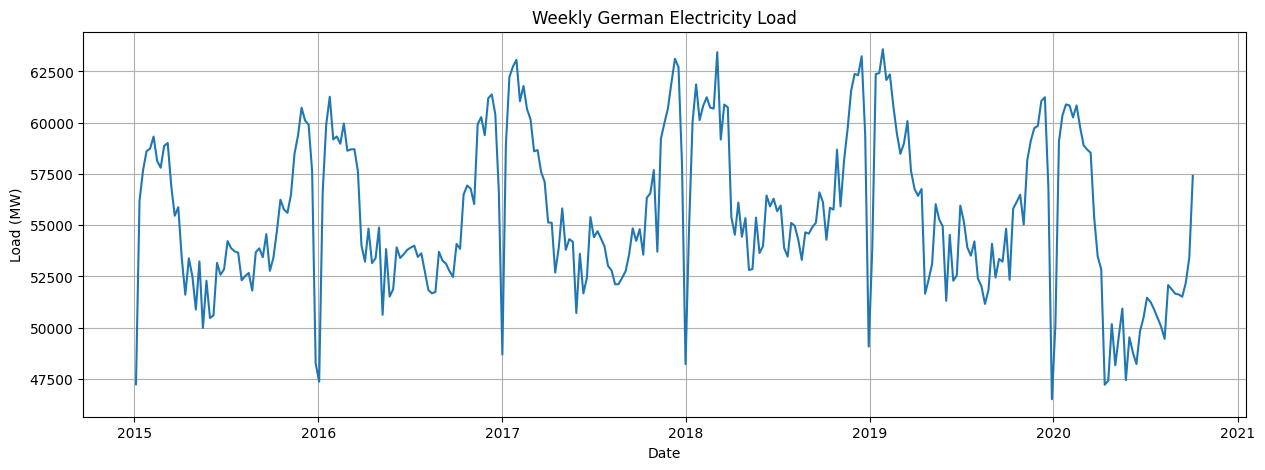

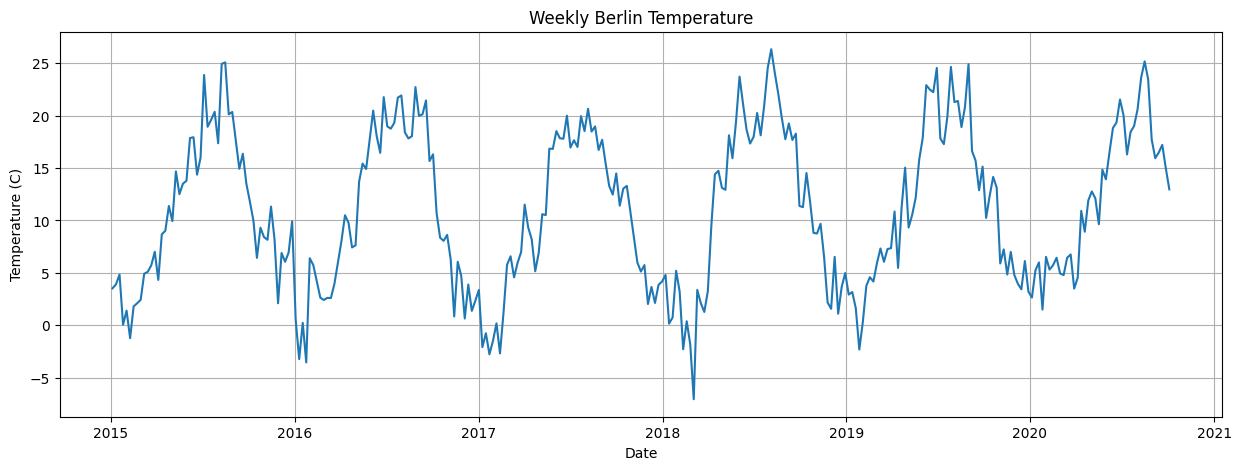

In [ ]:
# plot load and temperature separately
# I do this because they are on very different scales

plt.figure(figsize=(15, 5))
plt.plot(sarimax_data.index, sarimax_data["load"])
plt.title("Weekly German Electricity Load")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(sarimax_data.index, sarimax_data["temperature"])
plt.title("Weekly Berlin Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.grid(True)
plt.show()

In [ ]:
# same train-test split as previous parts
# last 104 weeks are used for testing

train_sx = sarimax_data[:-104]
test_sx = sarimax_data[-104:]

y_train = train_sx["load"]
y_test = test_sx["load"]

x_train = train_sx[["temperature"]]
x_test = test_sx[["temperature"]]

print("Train size:", len(y_train))
print("Test size:", len(y_test))

Train size: 197
Test size: 104


In [ ]:
sarimax_model = SARIMAX(
    y_train,
    exog=x_train,
    order=(3, 0, 2),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

print(sarimax_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  197
Model:             SARIMAX(3, 0, 2)x(1, 1, [1], 52)   Log Likelihood                -781.054
Date:                              Thu, 25 Jun 2026   AIC                           1580.107
Time:                                      13:31:41   BIC                           1602.606
Sample:                                  01-04-2015   HQIC                          1589.180
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
temperature  -102.4733     51.585     -1.986      0.047    -203.578      -1.368
ar.L1           

In [ ]:
# make forecast for the last 104 weeks
# x_test contains the temperature values for the test period

sarimax_forecast_object = sarimax_fit.get_forecast(
    steps=104,
    exog=x_test
)

sarimax_forecast = sarimax_forecast_object.predicted_mean
sarimax_ci = sarimax_forecast_object.conf_int()

In [ ]:
# evaluate SARIMAX

sarimax_rmse, sarimax_mae, sarimax_mape = evaluate(
    y_test,
    sarimax_forecast
)

print("SARIMAX with Temperature")
print("RMSE:", sarimax_rmse)
print("MAE:", sarimax_mae)
print("MAPE:", sarimax_mape)

SARIMAX with Temperature
RMSE: 2847.0789636192644
MAE: 2155.2202406450447
MAPE: 4.124607958369282


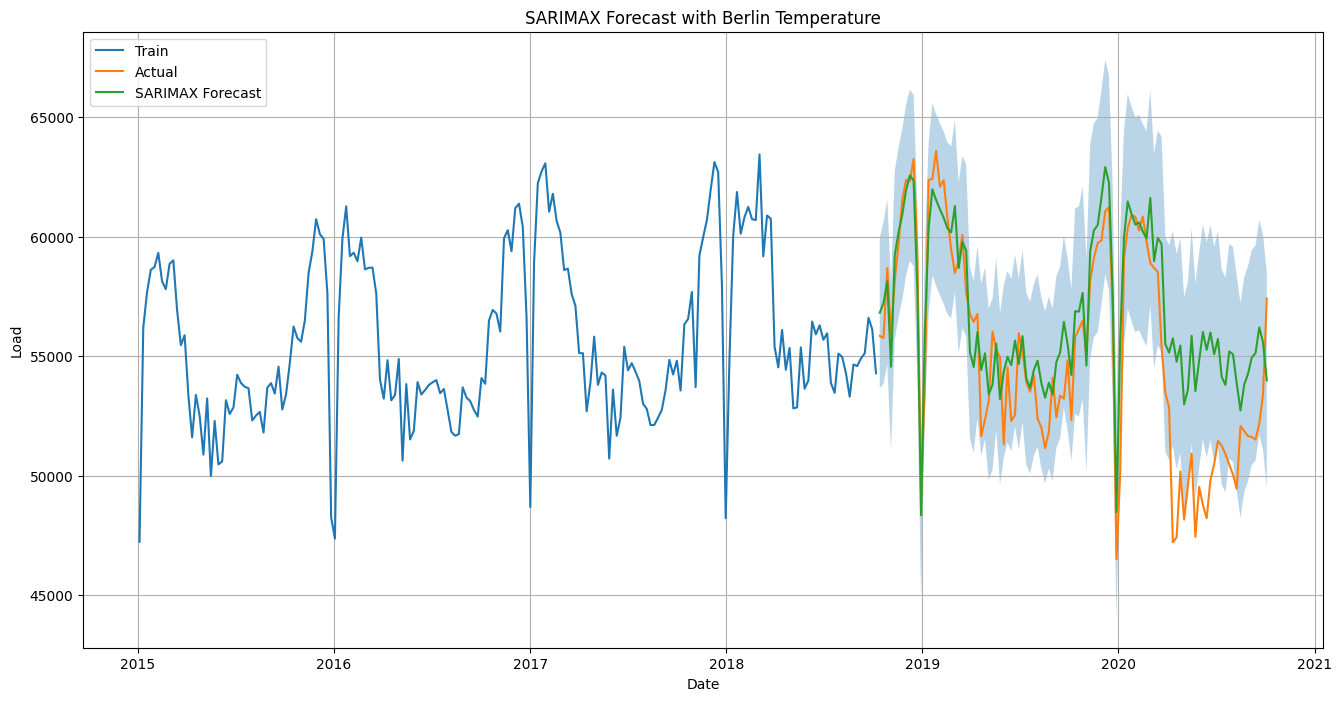

In [ ]:
# plot SARIMAX forecast with confidence interval

plt.figure(figsize=(16, 8))

plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, sarimax_forecast, label="SARIMAX Forecast")

plt.fill_between(
    y_test.index,
    sarimax_ci.iloc[:, 0],
    sarimax_ci.iloc[:, 1],
    alpha=0.3
)

plt.title("SARIMAX Forecast with Berlin Temperature")
plt.xlabel("Date")
plt.ylabel("Load")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# compare SARIMA and SARIMAX
# this shows whether temperature improved the model

part4_results = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "SARIMA",
        "SARIMAX Temperature"
    ],
    "RMSE": [
        sn_rmse,
        sarima_rmse,
        sarimax_rmse
    ],
    "MAE": [
        sn_mae,
        sarima_mae,
        sarimax_mae
    ],
    "MAPE": [
        sn_mape,
        sarima_mape,
        sarimax_mape
    ]
})

part4_results.sort_values("RMSE")

,Model,RMSE,MAE,MAPE
1,SARIMA,2788.722820,2149.284885,4.094311
2,SARIMAX Temperature,2847.078964,2155.220241,4.124608
0,Seasonal Naive,3006.760812,2318.520585,4.408920


In [ ]:
# check the temperature coefficient from the fitted model

print("Temperature coefficient:")
print(sarimax_fit.params["temperature"])

Temperature coefficient:
-102.4732863478684


In [ ]:
# SARIMAX with temperature and holiday covariates
# I add German public holidays to check whether holidays improve forecast accuracy

!pip -q install holidays

import holidays

In [ ]:
# creating German holiday calendar from 2015 to 2020

german_holidays = holidays.Germany(
    years=range(2015, 2021)
)

print("Number of holidays:", len(german_holidays))

Number of holidays: 55


In [ ]:
# creating a daily holiday indicator
# If the date is a public holiday, it gets value 1, otherwise 0

holiday_daily = pd.Series(
    [
        1 if day.date() in german_holidays else 0
        for day in daily_load.index
    ],
    index=daily_load.index
)

holiday_daily.head()

,0
timestamp,
2015-01-01 00:00:00+00:00,1
2015-01-02 00:00:00+00:00,0
2015-01-03 00:00:00+00:00,0
2015-01-04 00:00:00+00:00,0
2015-01-05 00:00:00+00:00,0


In [ ]:
# convert daily holiday indicator into weekly holiday count
# This gives number of public holidays in each week

weekly_holidays = holiday_daily.resample("W").sum()

weekly_holidays.head()

,0
timestamp,
2015-01-04 00:00:00+00:00,1
2015-01-11 00:00:00+00:00,0
2015-01-18 00:00:00+00:00,0
2015-01-25 00:00:00+00:00,0
2015-02-01 00:00:00+00:00,0


In [ ]:
# adding holiday count to the SARIMAX dataset

sarimax_holiday_data = sarimax_data.copy()

sarimax_holiday_data["holiday_count"] = weekly_holidays.reindex(
    sarimax_holiday_data.index
).fillna(0)

sarimax_holiday_data.head()

,load,temperature,holiday_count
2015-01-04 00:00:00+00:00,47233.739583,3.525000,1
2015-01-11 00:00:00+00:00,56191.101190,3.914286,0
2015-01-18 00:00:00+00:00,57672.678571,4.842857,0
2015-01-25 00:00:00+00:00,58613.303571,0.057143,0
2015-02-01 00:00:00+00:00,58734.029762,1.400000,0


In [ ]:
# train-test split for SARIMAX with temperature and holidays

train_holiday = sarimax_holiday_data[:-104]
test_holiday = sarimax_holiday_data[-104:]

y_train_holiday = train_holiday["load"]
y_test_holiday = test_holiday["load"]

x_train_holiday = train_holiday[
    ["temperature", "holiday_count"]
]

x_test_holiday = test_holiday[
    ["temperature", "holiday_count"]
]

print("Train size:", len(y_train_holiday))
print("Test size:", len(y_test_holiday))

Train size: 197
Test size: 104


In [ ]:
# SARIMAX model with temperature and holiday covariates

sarimax_holiday_model = SARIMAX(
    y_train_holiday,
    exog=x_train_holiday,
    order=(3, 0, 2),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_holiday_fit = sarimax_holiday_model.fit(
    disp=False
)

print(sarimax_holiday_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  197
Model:             SARIMAX(3, 0, 2)x(1, 1, [1], 52)   Log Likelihood                -757.312
Date:                              Thu, 25 Jun 2026   AIC                           1534.625
Time:                                      13:32:25   BIC                           1559.623
Sample:                                  01-04-2015   HQIC                          1544.705
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
temperature    -146.6176     30.894     -4.746      0.000    -207.169     -86.066
holiday_co

In [ ]:
# forecast with temperature and holiday covariates

sarimax_holiday_forecast_object = sarimax_holiday_fit.get_forecast(
    steps=104,
    exog=x_test_holiday
)

sarimax_holiday_forecast = sarimax_holiday_forecast_object.predicted_mean
sarimax_holiday_ci = sarimax_holiday_forecast_object.conf_int()

In [ ]:
# evaluate SARIMAX with temperature and holidays

sarimax_holiday_rmse, sarimax_holiday_mae, sarimax_holiday_mape = evaluate(
    y_test_holiday,
    sarimax_holiday_forecast
)

print("SARIMAX with Temperature and Holidays")
print("RMSE:", sarimax_holiday_rmse)
print("MAE:", sarimax_holiday_mae)
print("MAPE:", sarimax_holiday_mape)

SARIMAX with Temperature and Holidays
RMSE: 2670.12469350628
MAE: 1955.7765043353122
MAPE: 3.7529946853804423


In [ ]:
# compare SARIMA, SARIMAX temperature, and SARIMAX temperature + holidays

holiday_comparison = pd.DataFrame({
    "Model": [
        "SARIMA",
        "SARIMAX Temperature",
        "SARIMAX Temperature + Holidays"
    ],
    "RMSE": [
        sarima_rmse,
        sarimax_rmse,
        sarimax_holiday_rmse
    ],
    "MAE": [
        sarima_mae,
        sarimax_mae,
        sarimax_holiday_mae
    ],
    "MAPE": [
        sarima_mape,
        sarimax_mape,
        sarimax_holiday_mape
    ]
})

holiday_comparison

,Model,RMSE,MAE,MAPE
0,SARIMA,2788.722820,2149.284885,4.094311
1,SARIMAX Temperature,2847.078964,2155.220241,4.124608
2,SARIMAX Temperature + Holidays,2670.124694,1955.776504,3.752995


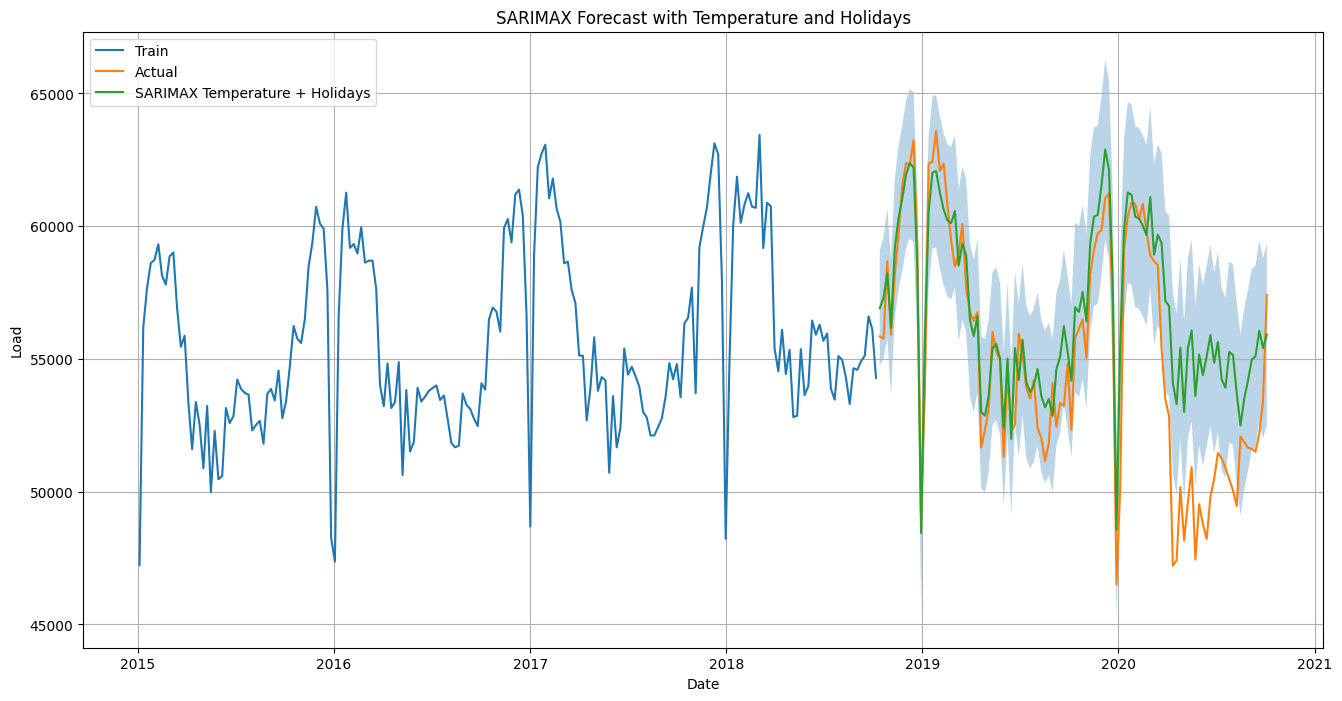

In [ ]:
# forecast plot for SARIMAX with temperature and holidays

plt.figure(figsize=(16, 8))

plt.plot(y_train_holiday.index, y_train_holiday, label="Train")
plt.plot(y_test_holiday.index, y_test_holiday, label="Actual")
plt.plot(
    y_test_holiday.index,
    sarimax_holiday_forecast,
    label="SARIMAX Temperature + Holidays"
)

plt.fill_between(
    y_test_holiday.index,
    sarimax_holiday_ci.iloc[:, 0],
    sarimax_holiday_ci.iloc[:, 1],
    alpha=0.3
)

plt.title("SARIMAX Forecast with Temperature and Holidays")
plt.xlabel("Date")
plt.ylabel("Load")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# PART 5: FEATURE BASED MODEL
# RANDOM FOREST

from sklearn.ensemble import RandomForestRegressor

In [ ]:
# I make a copy of the weekly load and temperature data

rf_data = sarimax_data.copy()

In [ ]:
# creating lag features
# these only use past values, so they avoid data leakage

rf_data["lag_1"] = rf_data["load"].shift(1)
rf_data["lag_2"] = rf_data["load"].shift(2)
rf_data["lag_3"] = rf_data["load"].shift(3)
rf_data["lag_52"] = rf_data["load"].shift(52)

# simple calendar features
rf_data["week"] = rf_data.index.isocalendar().week.astype(int)
rf_data["month"] = rf_data.index.month

rf_data = rf_data.dropna()

print(rf_data.head())
print(rf_data.shape)

                                   load  temperature         lag_1  \
2016-01-03 00:00:00+00:00  47364.035714     0.514286  48253.363095   
2016-01-10 00:00:00+00:00  56615.142857    -3.228571  47364.035714   
2016-01-17 00:00:00+00:00  59913.910714     0.228571  56615.142857   
2016-01-24 00:00:00+00:00  61267.529762    -3.542857  59913.910714   
2016-01-31 00:00:00+00:00  59185.089286     6.400000  61267.529762   

                                  lag_2         lag_3        lag_52  week  \
2016-01-03 00:00:00+00:00  57627.857143  59907.333333  47233.739583    53   
2016-01-10 00:00:00+00:00  48253.363095  57627.857143  56191.101190     1   
2016-01-17 00:00:00+00:00  47364.035714  48253.363095  57672.678571     2   
2016-01-24 00:00:00+00:00  56615.142857  47364.035714  58613.303571     3   
2016-01-31 00:00:00+00:00  59913.910714  56615.142857  58734.029762     4   

                           month  
2016-01-03 00:00:00+00:00      1  
2016-01-10 00:00:00+00:00      1  
2016-01-17 

In [ ]:
# selecting the input features and target variable

features = [
    "temperature",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_52",
    "week",
    "month"
]

X = rf_data[features]
y = rf_data["load"]

In [ ]:
# using the final 104 weeks as the test set again

train_size = len(rf_data) - 104

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 145
Test size: 104


In [ ]:
# building the random forest model

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=500, random_state=42)

In [ ]:
# forecasting the test period

rf_forecast = rf_model.predict(X_test)

In [ ]:
# evaluating the random forest model

rf_rmse, rf_mae, rf_mape = evaluate(
    y_test,
    rf_forecast
)

print("Random Forest")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("MAPE:", rf_mape)

Random Forest
RMSE: 2475.0680238661935
MAE: 1789.345117127177
MAPE: 3.435741253029191


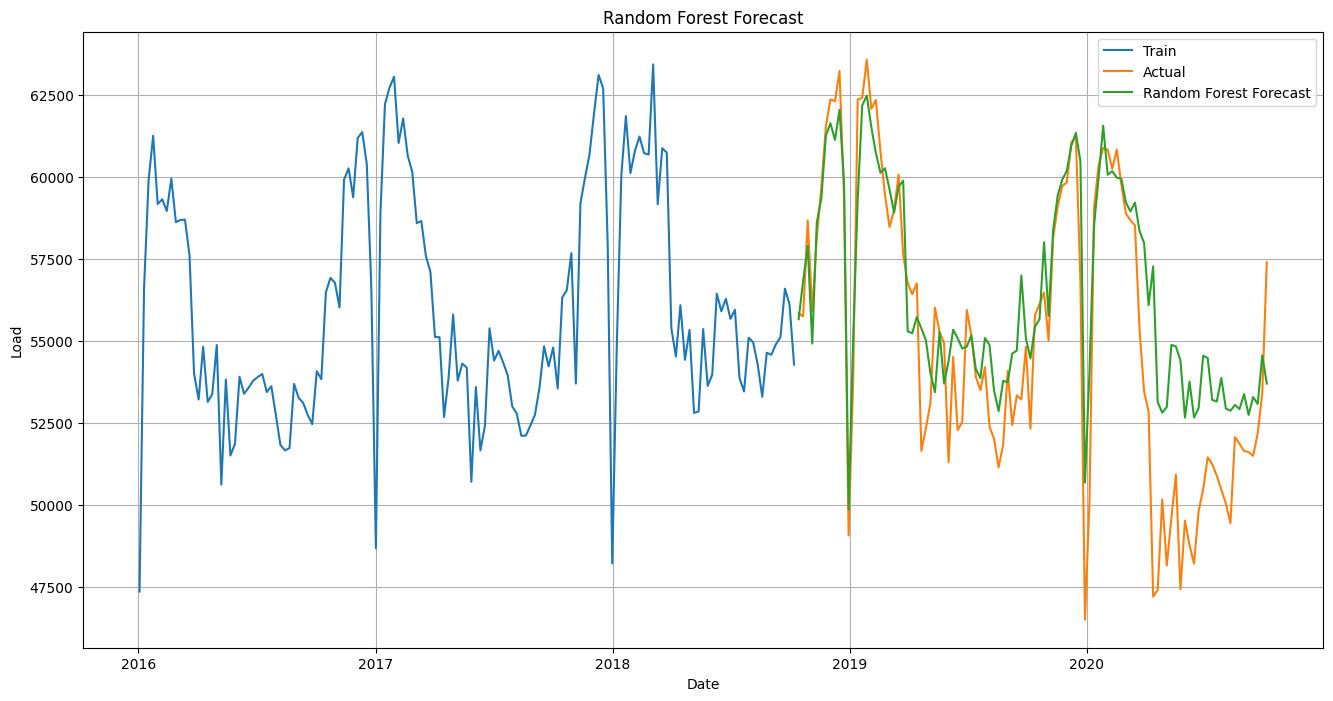

In [ ]:
# plot actual vs random forest forecast

plt.figure(figsize=(16, 8))

plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, rf_forecast, label="Random Forest Forecast")

plt.title("Random Forest Forecast")
plt.xlabel("Date")
plt.ylabel("Load")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# feature importance helps to explain the model

importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

       Feature  Importance
4       lag_52    0.783182
1        lag_1    0.068584
5         week    0.055773
0  temperature    0.043070
3        lag_3    0.027093
2        lag_2    0.016958
6        month    0.005341


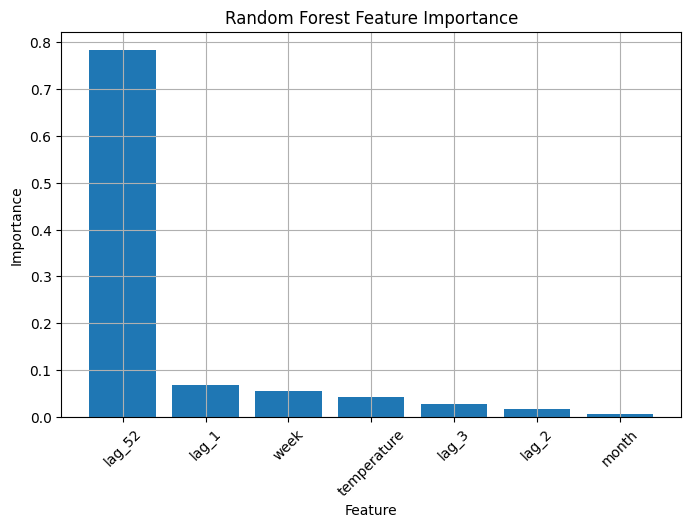

In [ ]:
# plot feature importance

plt.figure(figsize=(8, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# compare random forest with previous models

part5_results = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "SARIMA",
        "SARIMAX",
        "Random Forest"
    ],
    "RMSE": [
        sn_rmse,
        sarima_rmse,
        sarimax_rmse,
        rf_rmse
    ],
    "MAE": [
        sn_mae,
        sarima_mae,
        sarimax_mae,
        rf_mae
    ],
    "MAPE": [
        sn_mape,
        sarima_mape,
        sarimax_mape,
        rf_mape
    ]
})

part5_results.sort_values("RMSE")

,Model,RMSE,MAE,MAPE
3,Random Forest,2475.068024,1789.345117,3.435741
1,SARIMA,2788.722820,2149.284885,4.094311
2,SARIMAX,2847.078964,2155.220241,4.124608
0,Seasonal Naive,3006.760812,2318.520585,4.408920


In [ ]:
# PART 6: LSTM MODEL

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
# using only the hourly load column

hourly_load = df[["load"]].copy()

print(hourly_load.head())
print(hourly_load.shape)

                              load
timestamp                         
2015-01-01 00:00:00+00:00  41151.0
2015-01-01 01:00:00+00:00  40135.0
2015-01-01 02:00:00+00:00  39106.0
2015-01-01 03:00:00+00:00  38765.0
2015-01-01 04:00:00+00:00  38941.0
(50400, 1)


In [ ]:
# scaling is needed for LSTM models

scaler = MinMaxScaler()

scaled_load = scaler.fit_transform(
    hourly_load
)

In [ ]:
# last 2 years of hourly data for testing

hours_in_two_years = 24 * 365 * 2

train_data = scaled_load[:-hours_in_two_years]
test_data = scaled_load[-hours_in_two_years:]

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (32880, 1)
Test shape: (17520, 1)


In [ ]:
# I use the previous 168 hours, which is one week, to predict the next hour

lookback = 168

In [ ]:
# creating training sequences

X_train_lstm = []
y_train_lstm = []

for i in range(lookback, len(train_data)):
    X_train_lstm.append(train_data[i-lookback:i])
    y_train_lstm.append(train_data[i])

X_train_lstm = np.array(X_train_lstm)
y_train_lstm = np.array(y_train_lstm)

print(X_train_lstm.shape)
print(y_train_lstm.shape)

(32712, 168, 1)
(32712, 1)


In [ ]:
# creating test sequences
# I have added the last lookback values from the train set so the first test prediction has history

combined_data = np.concatenate(
    (train_data[-lookback:], test_data)
)

X_test_lstm = []
y_test_lstm = []

for i in range(lookback, len(combined_data)):
    X_test_lstm.append(combined_data[i-lookback:i])
    y_test_lstm.append(combined_data[i])

X_test_lstm = np.array(X_test_lstm)
y_test_lstm = np.array(y_test_lstm)

print(X_test_lstm.shape)
print(y_test_lstm.shape)

(17520, 168, 1)
(17520, 1)


In [ ]:
# building a simple LSTM model

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(
    LSTM(50)
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# training the LSTM

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.0207 - val_loss: 0.0032
Epoch 2/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 0.0064 - val_loss: 0.0023
Epoch 3/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0046 - val_loss: 0.0014
Epoch 4/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0035 - val_loss: 0.0010
Epoch 5/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0028 - val_loss: 6.9181e-04
Epoch 6/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0023 - val_loss: 5.9741e-04
Epoch 7/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0019 - val_loss: 5.1395e-04
Epoch 8/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0016 - val_loss: 4.5808e-04
Epoch 9/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0015 - val_loss: 4.5599e-04
Epoch 10/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0013 - val_loss: 5.2168e-04


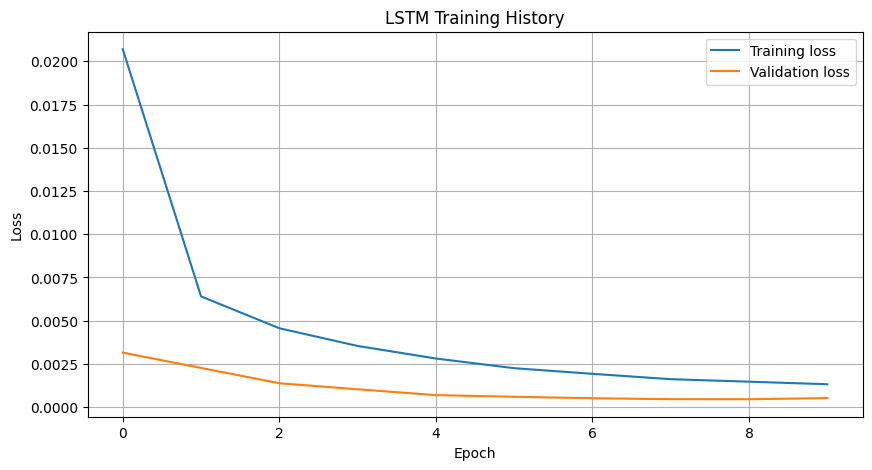

In [ ]:
# plot training and validation loss

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# forecasting the test period

lstm_forecast = lstm_model.predict(
    X_test_lstm
)

548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


In [ ]:
# converting predictions back to original scale

lstm_forecast = scaler.inverse_transform(
    lstm_forecast
)

y_test_actual = scaler.inverse_transform(
    y_test_lstm.reshape(-1, 1)
)

In [ ]:
# evaluating the LSTM model

lstm_rmse = np.sqrt(
    mean_squared_error(y_test_actual, lstm_forecast)
)

lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_forecast
)

lstm_mape = (
    np.mean(
        np.abs((y_test_actual - lstm_forecast) / y_test_actual)
    ) * 100
)

print("LSTM")
print("RMSE:", lstm_rmse)
print("MAE:", lstm_mae)
print("MAPE:", lstm_mape)

LSTM
RMSE: 1166.403950589439
MAE: 893.3128465905037
MAPE: 1.65780462466122


In [ ]:
# LSTM hyperparameter tuning without repeating full code

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

def make_sequences(series_data, lookback_hours):
    X, y = [], []

    for i in range(lookback_hours, len(series_data)):
        X.append(series_data[i-lookback_hours:i])
        y.append(series_data[i, 0])

    return np.array(X), np.array(y)


def run_lstm_tuning(name, lookback_hours, units_1, units_2=None, dropout=0.2, epochs=3):
    K.clear_session()

    X_train_temp, y_train_temp = make_sequences(train_data, lookback_hours)

    combined_temp = np.concatenate(
        (train_data[-lookback_hours:], test_data)
    )

    X_test_temp, y_test_temp = make_sequences(combined_temp, lookback_hours)

    model = Sequential()

    if units_2 is None:
        model.add(
            LSTM(
                units_1,
                input_shape=(X_train_temp.shape[1], X_train_temp.shape[2])
            )
        )
        model.add(Dropout(dropout))

    else:
        model.add(
            LSTM(
                units_1,
                return_sequences=True,
                input_shape=(X_train_temp.shape[1], X_train_temp.shape[2])
            )
        )
        model.add(Dropout(dropout))
        model.add(LSTM(units_2))
        model.add(Dropout(dropout))

    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    model.fit(
        X_train_temp,
        y_train_temp,
        epochs=epochs,
        batch_size=128,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    pred_scaled = model.predict(X_test_temp)

    pred = scaler.inverse_transform(pred_scaled).flatten()
    actual = scaler.inverse_transform(
        y_test_temp.reshape(-1, 1)
    ).flatten()

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100

    return {
        "Model": name,
        "Lookback Hours": lookback_hours,
        "Layer Design": f"{units_1}" if units_2 is None else f"{units_1} + {units_2}",
        "Dropout": dropout,
        "Epochs": epochs,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

In [ ]:
# Small tuning trials
# These are kept short so they do not take too long to run

lstm_tuning_results = []

lstm_tuning_results.append(
    run_lstm_tuning(
        name="Trial 1",
        lookback_hours=24,
        units_1=32,
        units_2=None,
        dropout=0.2,
        epochs=3
    )
)

lstm_tuning_results.append(
    run_lstm_tuning(
        name="Trial 2",
        lookback_hours=336,
        units_1=64,
        units_2=32,
        dropout=0.25,
        epochs=3
    )
)

# Add your already completed final LSTM result

lstm_tuning_results.append({
    "Model": "Final LSTM",
    "Lookback Hours": 168,
    "Layer Design": "50 + 50",
    "Dropout": 0.2,
    "Epochs": 10,
    "RMSE": lstm_rmse,
    "MAE": lstm_mae,
    "MAPE": lstm_mape
})

lstm_tuning_table = pd.DataFrame(lstm_tuning_results)

lstm_tuning_table.sort_values("RMSE")

Epoch 1/3
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0406 - val_loss: 0.0104
Epoch 2/3
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0119 - val_loss: 0.0086
Epoch 3/3
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0089 - val_loss: 0.0042
548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Epoch 1/3
229/229 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0301 - val_loss: 0.0075
Epoch 2/3
229/229 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0108 - val_loss: 0.0034
Epoch 3/3
229/229 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0075 - val_loss: 0.0018
548/548 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


,Model,Lookback Hours,Layer Design,Dropout,Epochs,RMSE,MAE,MAPE
2,Final LSTM,168,50 + 50,0.20,10,1166.403951,893.312847,1.657805
1,Trial 2,336,64 + 32,0.25,3,2377.656004,1803.998098,3.443007
0,Trial 1,24,32,0.20,3,3000.510073,2382.042882,4.491696


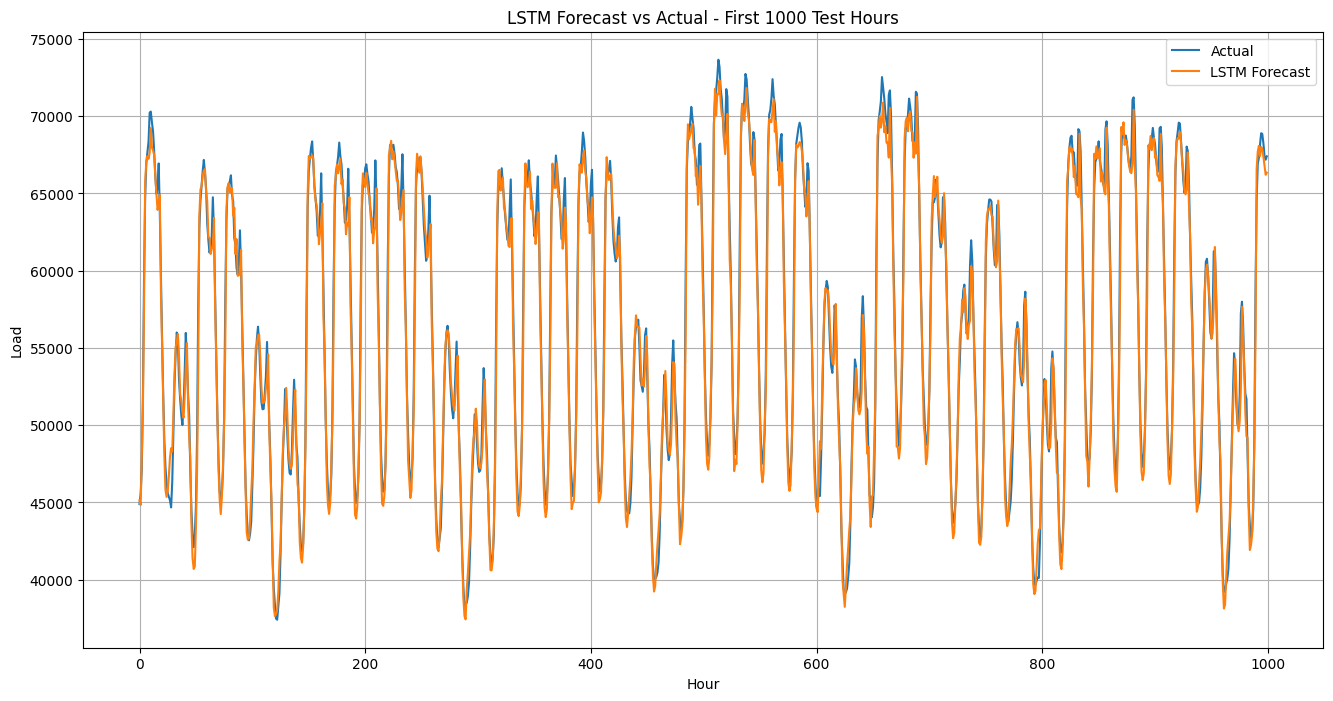

In [ ]:
# plot first 1000 hours only because plotting all hours is too crowded

plt.figure(figsize=(16, 8))

plt.plot(y_test_actual[:1000], label="Actual")
plt.plot(lstm_forecast[:1000], label="LSTM Forecast")

plt.title("LSTM Forecast vs Actual - First 1000 Test Hours")
plt.xlabel("Hour")
plt.ylabel("Load")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# final comparison table
# note: LSTM is hourly while the other models use weekly data,

final_results = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "SARIMA",
        "SARIMAX",
        "Random Forest",
        "LSTM"
    ],
    "RMSE": [
        sn_rmse,
        sarima_rmse,
        sarimax_rmse,
        rf_rmse,
        lstm_rmse
    ],
    "MAE": [
        sn_mae,
        sarima_mae,
        sarimax_mae,
        rf_mae,
        lstm_mae
    ],
    "MAPE": [
        sn_mape,
        sarima_mape,
        sarimax_mape,
        rf_mape,
        lstm_mape
    ]
})

final_results.sort_values("RMSE")

,Model,RMSE,MAE,MAPE
4,LSTM,1166.403951,893.312847,1.657805
3,Random Forest,2475.068024,1789.345117,3.435741
1,SARIMA,2788.722820,2149.284885,4.094311
2,SARIMAX,2847.078964,2155.220241,4.124608
0,Seasonal Naive,3006.760812,2318.520585,4.408920
